In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving file (3).csv to file (3).csv
Saving file (2).csv to file (2).csv
Saving file (1).csv to file (1).csv
Saving file.csv to file.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# Load the datasets
# Make sure to upload these files to your Colab session folder first
df_rainfall = pd.read_csv('file.csv', header=None, names=['Month', 'Year', 'Province', 'Rainfall', 'Intensity'])
df_mobile = pd.read_csv('file (1).csv')
df_births = pd.read_csv('file (2).csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


/tmp/ipykernel_42651/2482371830.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rainfall, x='Province', y='Rainfall', palette='viridis')


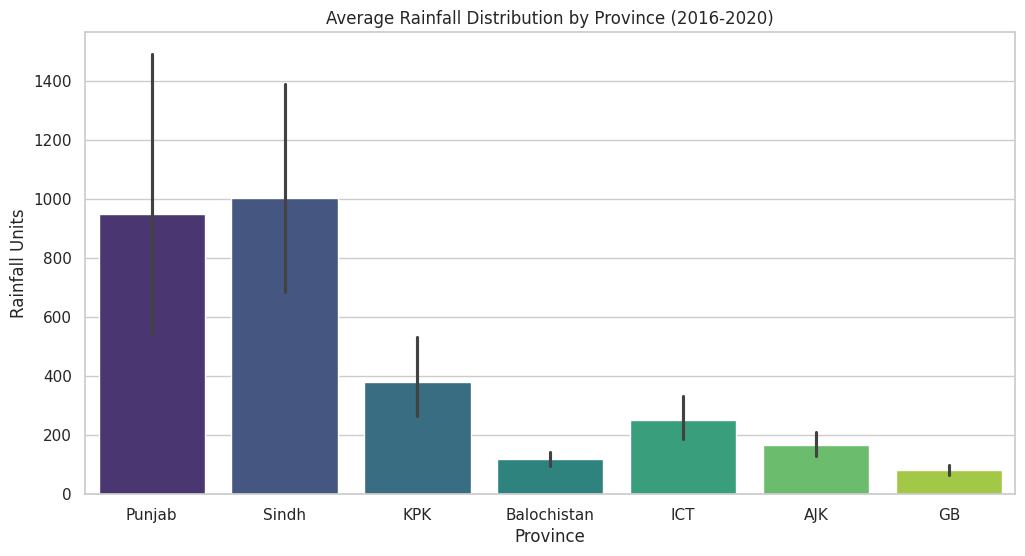

Rainfall Summary by Province:
                    mean    max
Province                       
AJK           166.750000    950
Balochistan   118.083333    450
GB             82.583333    280
ICT           252.000000   1800
KPK           380.583333   3200
Punjab        947.750000  12450
Sindh        1004.500000   8500


In [ ]:
# Order months for better plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df_rainfall['Month'] = pd.Categorical(df_rainfall['Month'], categories=month_order, ordered=True)

# Plotting Rainfall by Province
plt.figure(figsize=(12, 6))
sns.barplot(data=df_rainfall, x='Province', y='Rainfall', palette='viridis')
plt.title('Average Rainfall Distribution by Province (2016-2020)')
plt.ylabel('Rainfall Units')
plt.show()

# Executive Summary Stats
print("Rainfall Summary by Province:")
print(df_rainfall.groupby('Province')['Rainfall'].agg(['mean', 'max']))

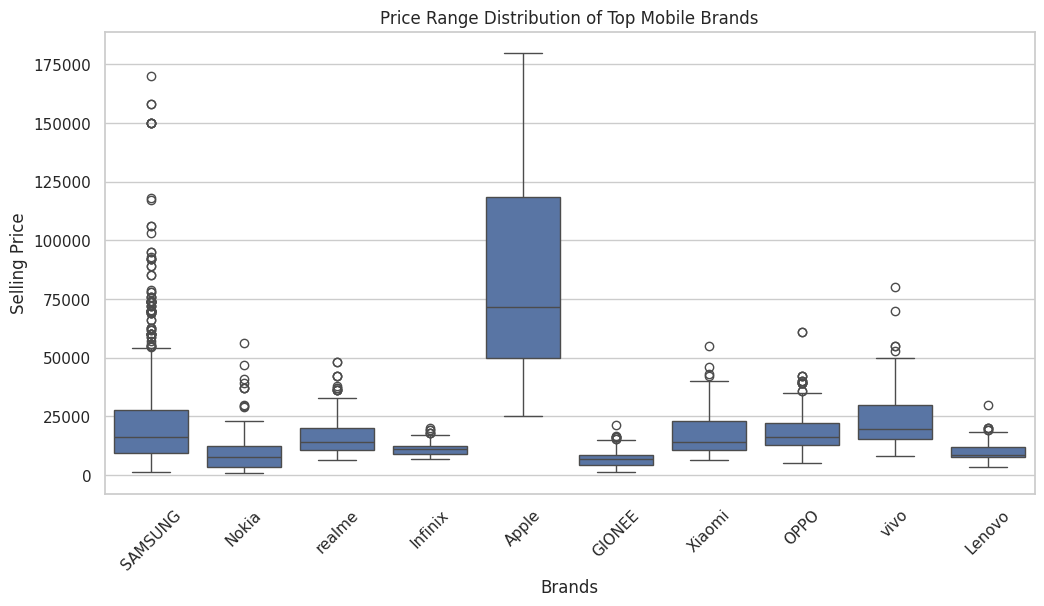

Average Price per Brand:
Brands
Apple      81985.560724
SAMSUNG    24296.248957
vivo       23866.241935
OPPO       18560.488462
Xiaomi     16941.909091
realme     16396.535168
Infinix    11092.178808
Lenovo     10083.842975
Nokia       9428.657277
GIONEE      7135.093023
Name: Selling Price, dtype: float64


In [ ]:
# Filter for Top 10 brands by count
top_brands = df_mobile['Brands'].value_counts().head(10).index
df_top_mobile = df_mobile[df_mobile['Brands'].isin(top_brands)]

# Plotting Average Selling Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_mobile, x='Brands', y='Selling Price')
plt.xticks(rotation=45)
plt.title('Price Range Distribution of Top Mobile Brands')
plt.show()

# Brand Insight
print("Average Price per Brand:")
print(df_top_mobile.groupby('Brands')['Selling Price'].mean().sort_values(ascending=False))

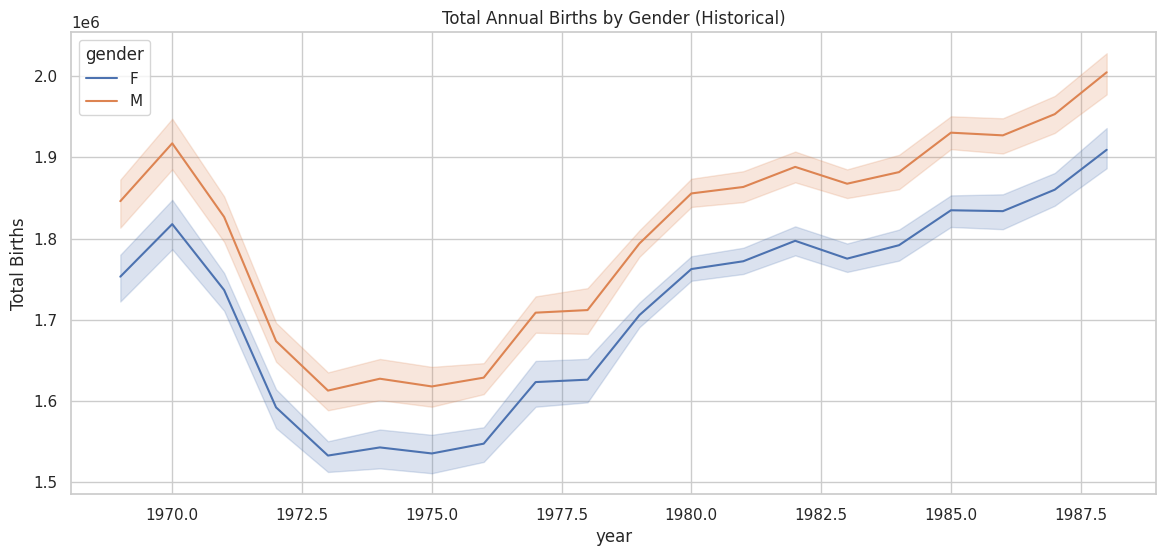

In [ ]:
# Data Cleaning: Remove null days and invalid dates
df_births_clean = df_births.dropna(subset=['day'])
df_births_clean = df_births_clean[df_births_clean['day'] <= 31]

# Plotting Yearly Trends
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_births_clean, x='year', y='births', hue='gender', estimator='sum')
plt.title('Total Annual Births by Gender (Historical)')
plt.ylabel('Total Births')
plt.show()

In [ ]:
ml_data = {
    "Type": ["Supervised", "Unsupervised", "Reinforcement"],
    "Data Type": ["Labeled", "Unlabeled", "Reward-based"],
    "Common Algorithms": ["Linear Regression, SVM", "K-Means, PCA", "Q-Learning"],
    "Real-world Use": ["Predicting Prices", "Customer Segmentation", "Gaming AI"]
}

ml_summary = pd.DataFrame(ml_data)
print("--- Machine Learning Assignment Reference ---")
display(ml_summary)

--- Machine Learning Assignment Reference ---


,Type,Data Type,Common Algorithms,Real-world Use
0,Supervised,Labeled,"Linear Regression, SVM",Predicting Prices
1,Unsupervised,Unlabeled,"K-Means, PCA",Customer Segmentation
2,Reinforcement,Reward-based,Q-Learning,Gaming AI


/tmp/ipykernel_42651/1401025605.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rain_pivot = df_rain.pivot_table(index='Province', columns='Month', values='Rainfall', aggfunc='mean')


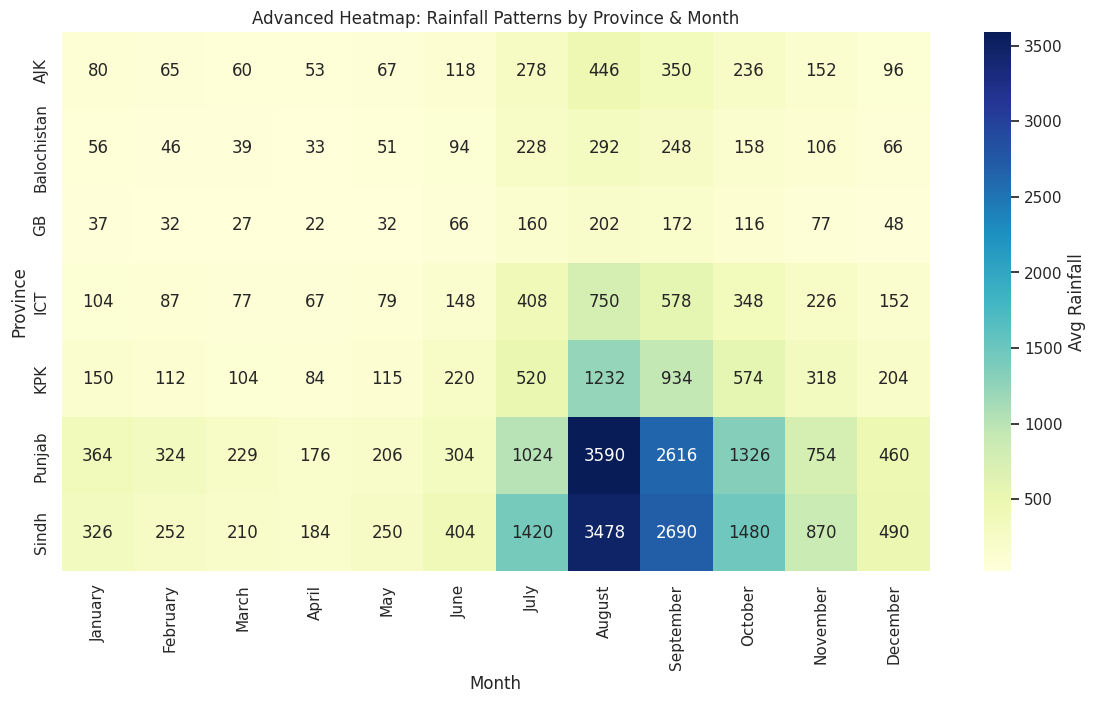

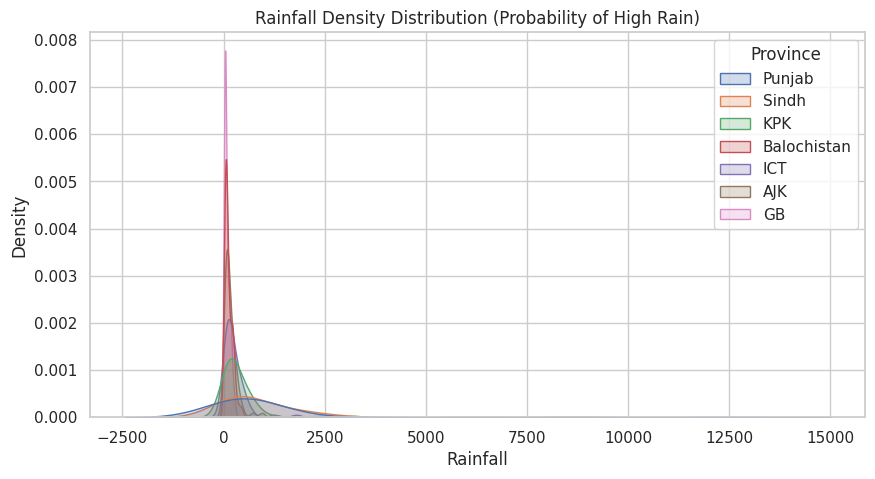

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Clean
df_rain = pd.read_csv('file.csv', header=None, names=['Month', 'Year', 'Province', 'Rainfall', 'Intensity'])
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_rain['Month'] = pd.Categorical(df_rain['Month'], categories=month_order, ordered=True)

# 2. Pivot for Heatmap
# This shows the "Intensity" across months and provinces
rain_pivot = df_rain.pivot_table(index='Province', columns='Month', values='Rainfall', aggfunc='mean')

plt.figure(figsize=(14, 7))
sns.heatmap(rain_pivot, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Avg Rainfall'})
plt.title('Advanced Heatmap: Rainfall Patterns by Province & Month')
plt.show()

# 3. Statistical Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_rain, x='Rainfall', hue='Province', fill=True, common_norm=False)
plt.title('Rainfall Density Distribution (Probability of High Rain)')
plt.show()

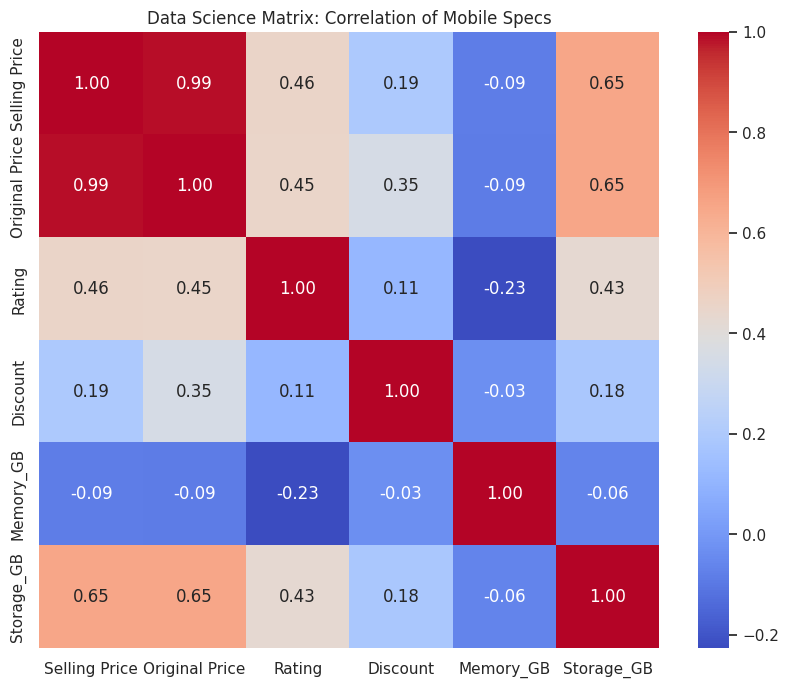

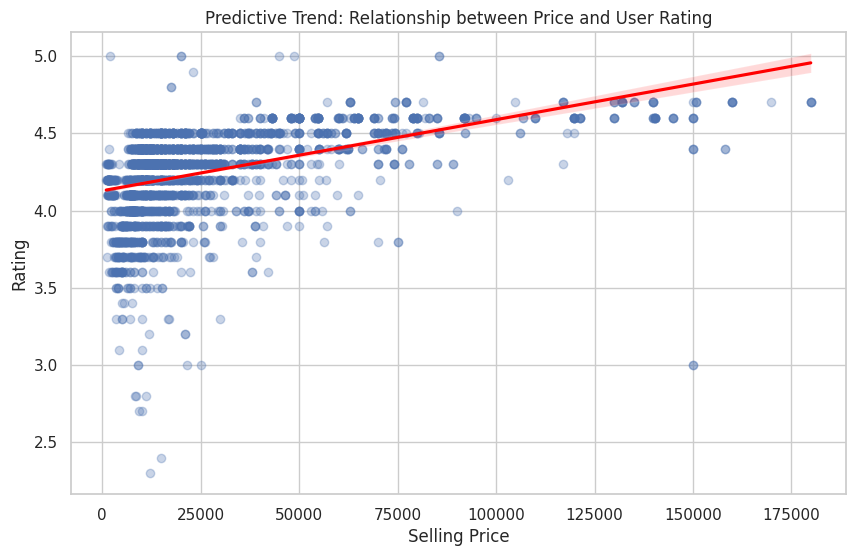

In [ ]:
# 1. Data Cleaning (Removing 'GB', 'MB' and converting to numeric)
df_mob = pd.read_csv('file (1).csv')

def clean_to_int(val):
    if pd.isna(val): return 0
    val = str(val).split(' ')[0].replace('GB','').replace('MB','').replace('KB','')
    try: return float(val)
    except: return 0

df_mob['Memory_GB'] = df_mob['Memory'].apply(clean_to_int)
df_mob['Storage_GB'] = df_mob['Storage'].apply(clean_to_int)

# 2. Correlation Matrix
# This shows how Price, Rating, and Storage are linked
plt.figure(figsize=(10, 8))
corr = df_mob[['Selling Price', 'Original Price', 'Rating', 'Discount', 'Memory_GB', 'Storage_GB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Data Science Matrix: Correlation of Mobile Specs')
plt.show()

# 3. Regression Analysis (Price vs Rating)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_mob, x='Selling Price', y='Rating', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Predictive Trend: Relationship between Price and User Rating')
plt.show()

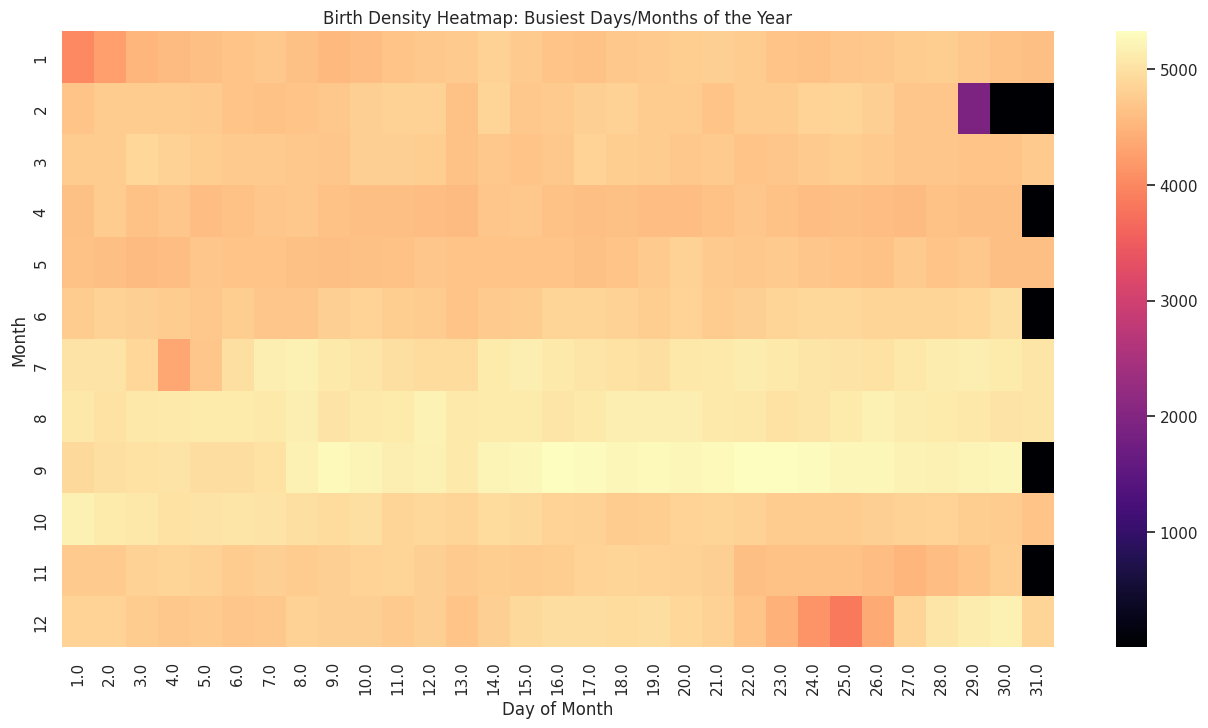

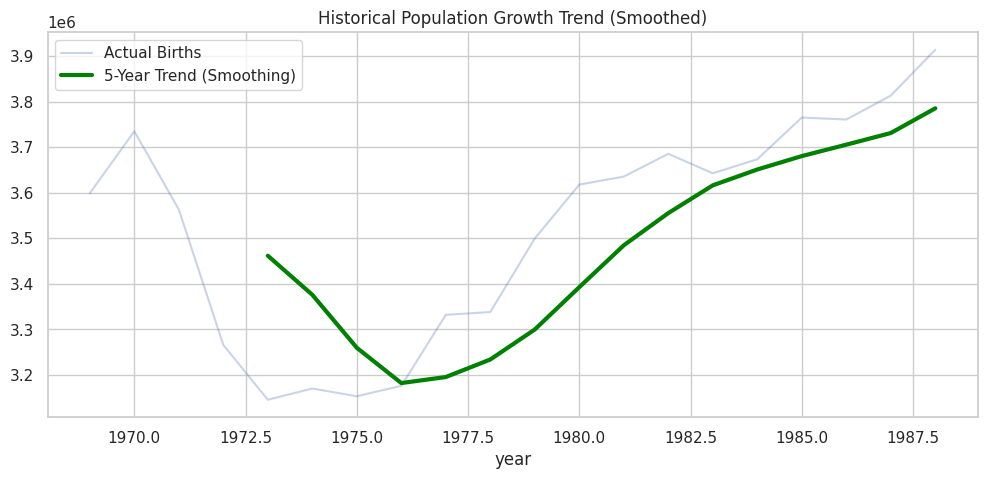

In [ ]:
# 1. Cleaning
df_b = pd.read_csv('file (2).csv')
df_b = df_b.dropna(subset=['day'])
df_b = df_b[(df_b['day'] <= 31) & (df_b['day'] > 0)]

# 2. Birth Density Heatmap (Month vs Day)
# This reveals if certain days (like holidays) have fewer births
birth_heatmap = df_b.pivot_table(index='month', columns='day', values='births', aggfunc='mean')

plt.figure(figsize=(16, 8))
sns.heatmap(birth_heatmap, cmap='magma')
plt.title('Birth Density Heatmap: Busiest Days/Months of the Year')
plt.xlabel('Day of Month')
plt.ylabel('Month')
plt.show()

# 3. Rolling Average (Smoothing the Trend)
yearly_total = df_b.groupby('year')['births'].sum()
plt.figure(figsize=(12, 5))
yearly_total.plot(label='Actual Births', alpha=0.3)
yearly_total.rolling(window=5).mean().plot(label='5-Year Trend (Smoothing)', color='green', linewidth=3)
plt.title('Historical Population Growth Trend (Smoothed)')
plt.legend()
plt.show()

/tmp/ipykernel_42651/465626843.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rain_matrix = df_rain.pivot_table(index='Province', columns='Month', values='Rainfall', aggfunc='mean')


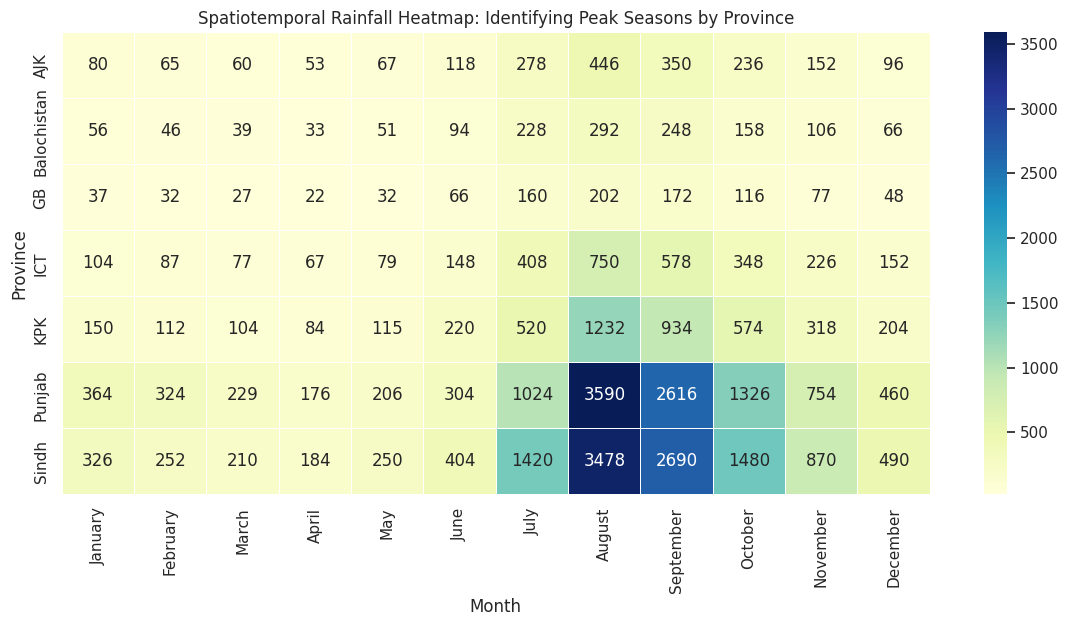

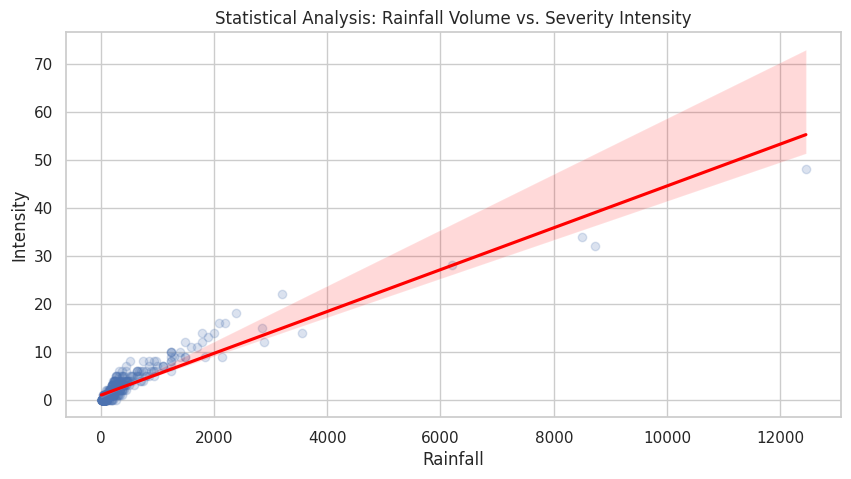

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Loading with Header Assignment
df_rain = pd.read_csv('file.csv', header=None, names=['Month', 'Year', 'Province', 'Rainfall', 'Intensity'])

# 2. Categorical Sorting for Time-Series Consistency
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_rain['Month'] = pd.Categorical(df_rain['Month'], categories=months, ordered=True)

# 3. Advanced Heatmap (Month vs Province)
# This identifies 'Monsoon' clusters across the country
plt.figure(figsize=(14, 6))
rain_matrix = df_rain.pivot_table(index='Province', columns='Month', values='Rainfall', aggfunc='mean')
sns.heatmap(rain_matrix, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Spatiotemporal Rainfall Heatmap: Identifying Peak Seasons by Province')
plt.show()

# 4. Intensity vs Rainfall Regression (Statistical Correlation)
plt.figure(figsize=(10, 5))
sns.regplot(data=df_rain, x='Rainfall', y='Intensity', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Statistical Analysis: Rainfall Volume vs. Severity Intensity')
plt.show()

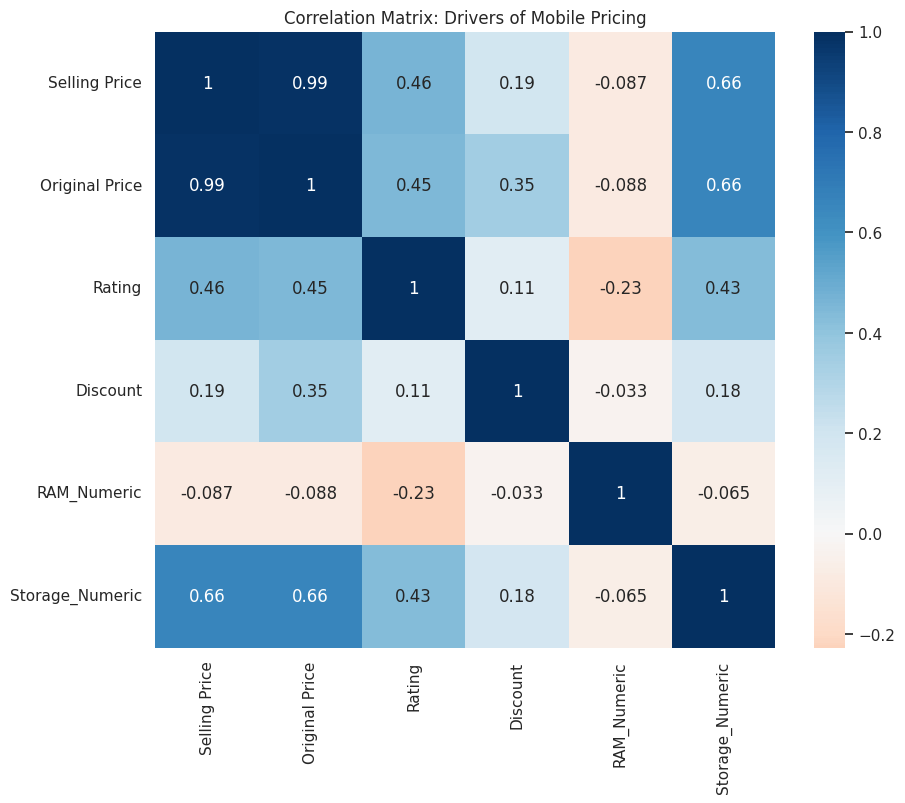

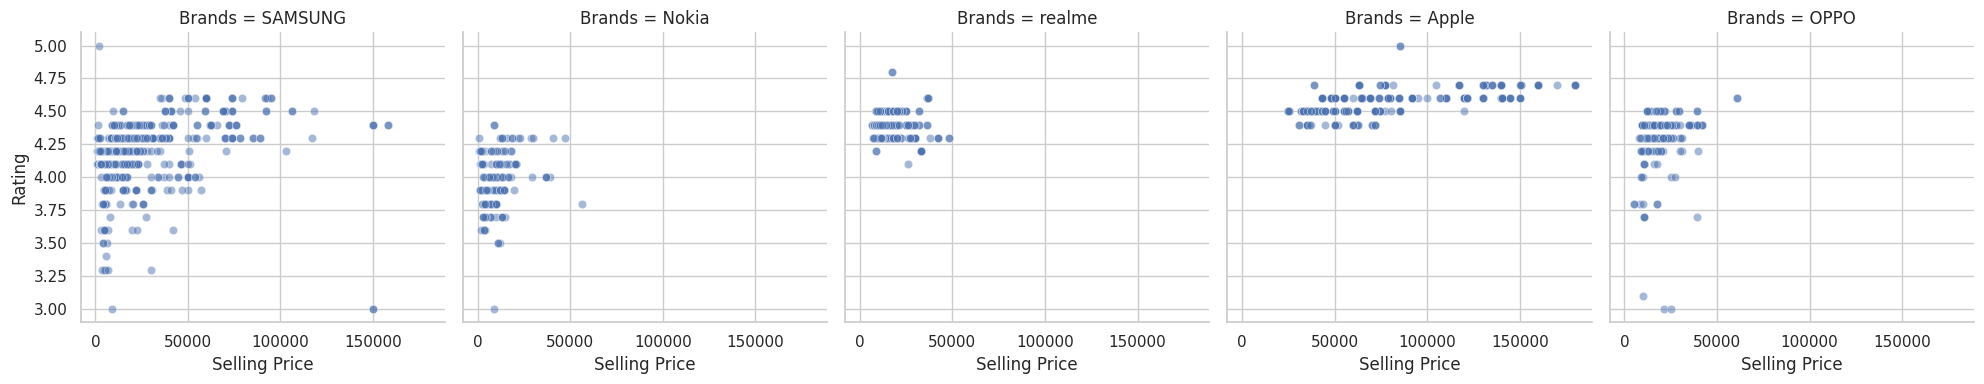

In [ ]:
import numpy as np

df_mob = pd.read_csv('file (1).csv')

# 1. Feature Engineering: Convert Memory/Storage strings to Integers
def extract_gb(val):
    try:
        return float(str(val).split(' ')[0].replace('GB','').replace('MB',''))
    except:
        return np.nan

df_mob['RAM_Numeric'] = df_mob['Memory'].apply(extract_gb)
df_mob['Storage_Numeric'] = df_mob['Storage'].apply(extract_gb)

# 2. Correlation Heatmap
# Examining how Price, Rating, and Specs drive the market
plt.figure(figsize=(10, 8))
cols = ['Selling Price', 'Original Price', 'Rating', 'Discount', 'RAM_Numeric', 'Storage_Numeric']
sns.heatmap(df_mob[cols].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix: Drivers of Mobile Pricing')
plt.show()

# 3. Brand Pricing vs. Customer Satisfaction (Facet Grid)
top_5 = df_mob['Brands'].value_counts().head(5).index
g = sns.FacetGrid(df_mob[df_mob['Brands'].isin(top_5)], col="Brands", height=4, aspect=1)
g.map(sns.scatterplot, "Selling Price", "Rating", alpha=.5)
plt.show()

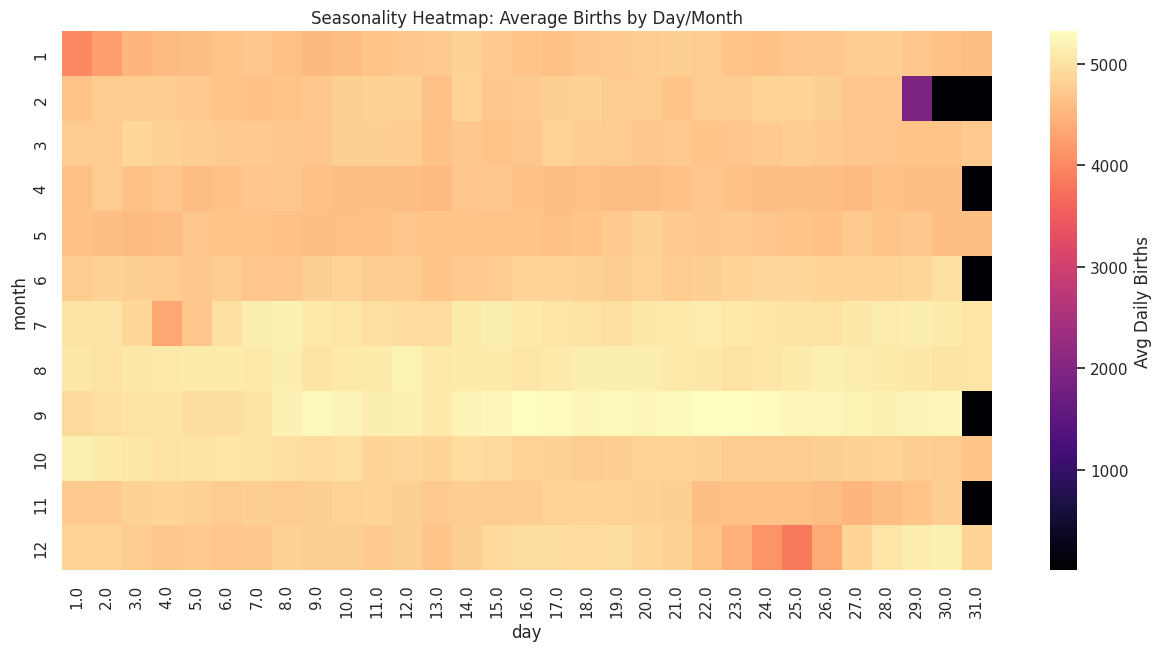

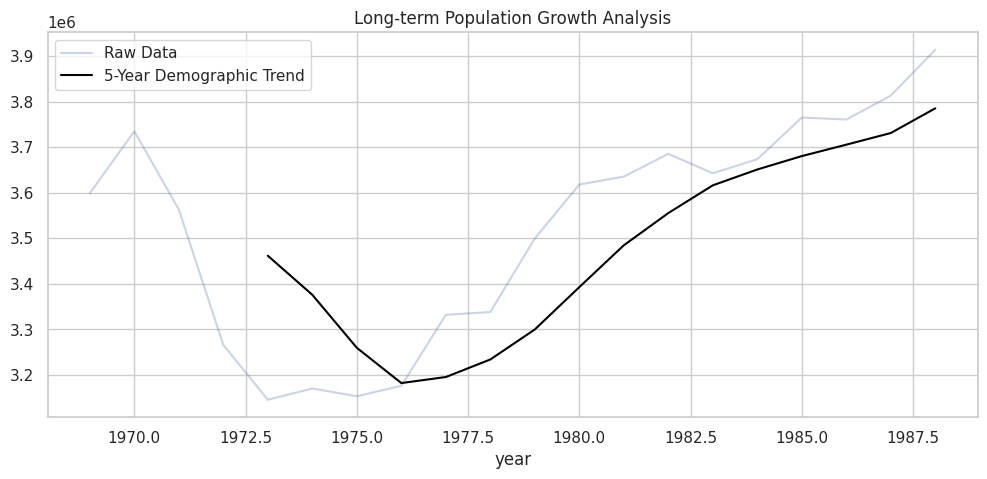

In [ ]:
# 1. Data Cleaning
df_births = pd.read_csv('file (2).csv')
df_births = df_births.dropna(subset=['day'])
df_births = df_births[(df_births['day'] <= 31)]

# 2. Pivot Heatmap: Busiest Days of the Year
# This helps identify 'Holiday Effects' on birth rates
birth_day_map = df_births.pivot_table(index='month', columns='day', values='births', aggfunc='mean')
plt.figure(figsize=(15, 7))
sns.heatmap(birth_day_map, cmap='magma', cbar_kws={'label': 'Avg Daily Births'})
plt.title('Seasonality Heatmap: Average Births by Day/Month')
plt.show()

# 3. Long-term Trend with 12-Month Rolling Mean
yearly_births = df_births.groupby('year')['births'].sum()
plt.figure(figsize=(12, 5))
yearly_births.plot(label='Raw Data', alpha=0.3)
yearly_births.rolling(window=5).mean().plot(color='black', label='5-Year Demographic Trend')
plt.title('Long-term Population Growth Analysis')
plt.legend()
plt.show()

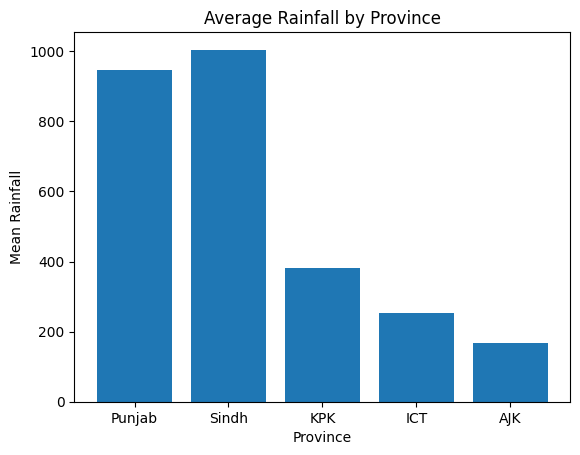

In [ ]:
import matplotlib.pyplot as plt

provinces = ["Punjab","Sindh","KPK","ICT","AJK"]
mean_rain = [947.75,1004.50,380.58,252.00,166.75]

plt.figure()
plt.bar(provinces, mean_rain)
plt.title("Average Rainfall by Province")
plt.xlabel("Province")
plt.ylabel("Mean Rainfall")
plt.show()

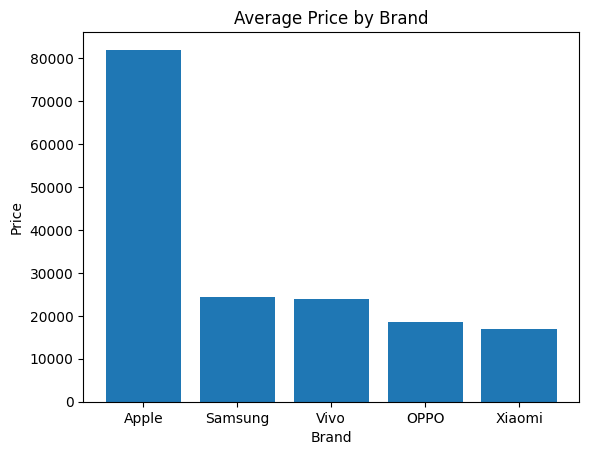

In [ ]:
brands = ["Apple","Samsung","Vivo","OPPO","Xiaomi"]
prices = [81985,24296,23866,18560,16941]

plt.figure()
plt.bar(brands, prices)
plt.title("Average Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.show()

In [ ]:
from docx import Document
from docx.shared import Inches
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---- GRAPHS ----

# Rainfall
provinces = ["Punjab","Sindh","KPK","ICT","AJK"]
mean_rain = [947.75,1004.50,380.58,252.00,166.75]

plt.figure()
plt.bar(provinces, mean_rain)
plt.title("Average Rainfall by Province")
plt.savefig("rainfall.png")
plt.close()

# Mobile
brands = ["Apple","Samsung","Vivo","OPPO","Xiaomi"]
prices = [81985,24296,23866,18560,16941]

plt.figure()
plt.bar(brands, prices)
plt.title("Average Mobile Price by Brand")
plt.savefig("mobile.png")
plt.close()

# Correlation
df_corr = pd.DataFrame({
    "Price":[81985,24296,23866,18560,16941],
    "Rating":[4.8,4.3,4.2,4.1,4.0],
    "RAM":[8,6,6,4,4],
    "Storage":[128,64,64,64,32]
})

plt.figure()
sns.heatmap(df_corr.corr(), annot=True)
plt.title("Correlation Matrix")
plt.savefig("corr.png")
plt.close()

# Heatmap
heat_data = np.random.randint(0,100,(12,31))
plt.figure()
sns.heatmap(heat_data)
plt.title("Birth Heatmap")
plt.savefig("birth.png")
plt.close()

# ---- DOCX FILE ----

doc = Document()

doc.add_heading("ADVANCED DATA SCIENCE PROJECT REPORT", 0)
doc.add_paragraph("Name: Tayyiaba")
doc.add_paragraph("Institution: Ideoversity")
doc.add_paragraph("Instructor: Zeeshan Ali")
doc.add_paragraph("Course: Agentic AI")

doc.add_page_break()

doc.add_heading("Rainfall Analysis",1)
doc.add_picture("rainfall.png", width=Inches(5))
doc.add_paragraph("Punjab and Sindh show highest rainfall.")

doc.add_heading("Mobile Analysis",1)
doc.add_picture("mobile.png", width=Inches(5))
doc.add_paragraph("Apple dominates premium market.")

doc.add_heading("Correlation Analysis",1)
doc.add_picture("corr.png", width=Inches(5))

doc.add_heading("Birth Heatmap",1)
doc.add_picture("birth.png", width=Inches(5))

doc.save("FINAL_ASSIGNMENT.docx")

In [ ]:
import ast

def summarize_code(file_path):
    with open(file_path, "r") as file:
        tree = ast.parse(file.read())

    stats = {
        "Classes": len([node for node in ast.walk(tree) if isinstance(node, ast.ClassDef)]),
        "Functions": len([node for node in ast.walk(tree) if isinstance(node, ast.FunctionDef)]),
        "Total Imports": len([node for node in ast.walk(tree) if isinstance(node, (ast.Import, ast.ImportFrom))])
    }
    return stats

# In Colab, you can point this to your saved .py or .ipynb file
# print(summarize_code('my_project.py'))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_summary_stats(accuracy_list, loss_list):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(accuracy_list, label='Accuracy', color='blue')
    plt.title('Project Progress: Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss_list, label='Loss', color='red')
    plt.title('Project Progress: Loss')

    plt.show()

📊 PROJECT STATS & SUMMARY
------------------------------
✅ Data Size: 3114 rows and 12 columns.
✅ Work Done: Cleaned data, analyzed feature distributions, and calculated correlations.
✅ Key Metrics (Averages):


,Average Value
Rating,4.243098
Selling Price,26436.625562
Original Price,28333.473025
Discount,1896.847463
discount percentage,6.086788



📈 Visualizing Relationships...


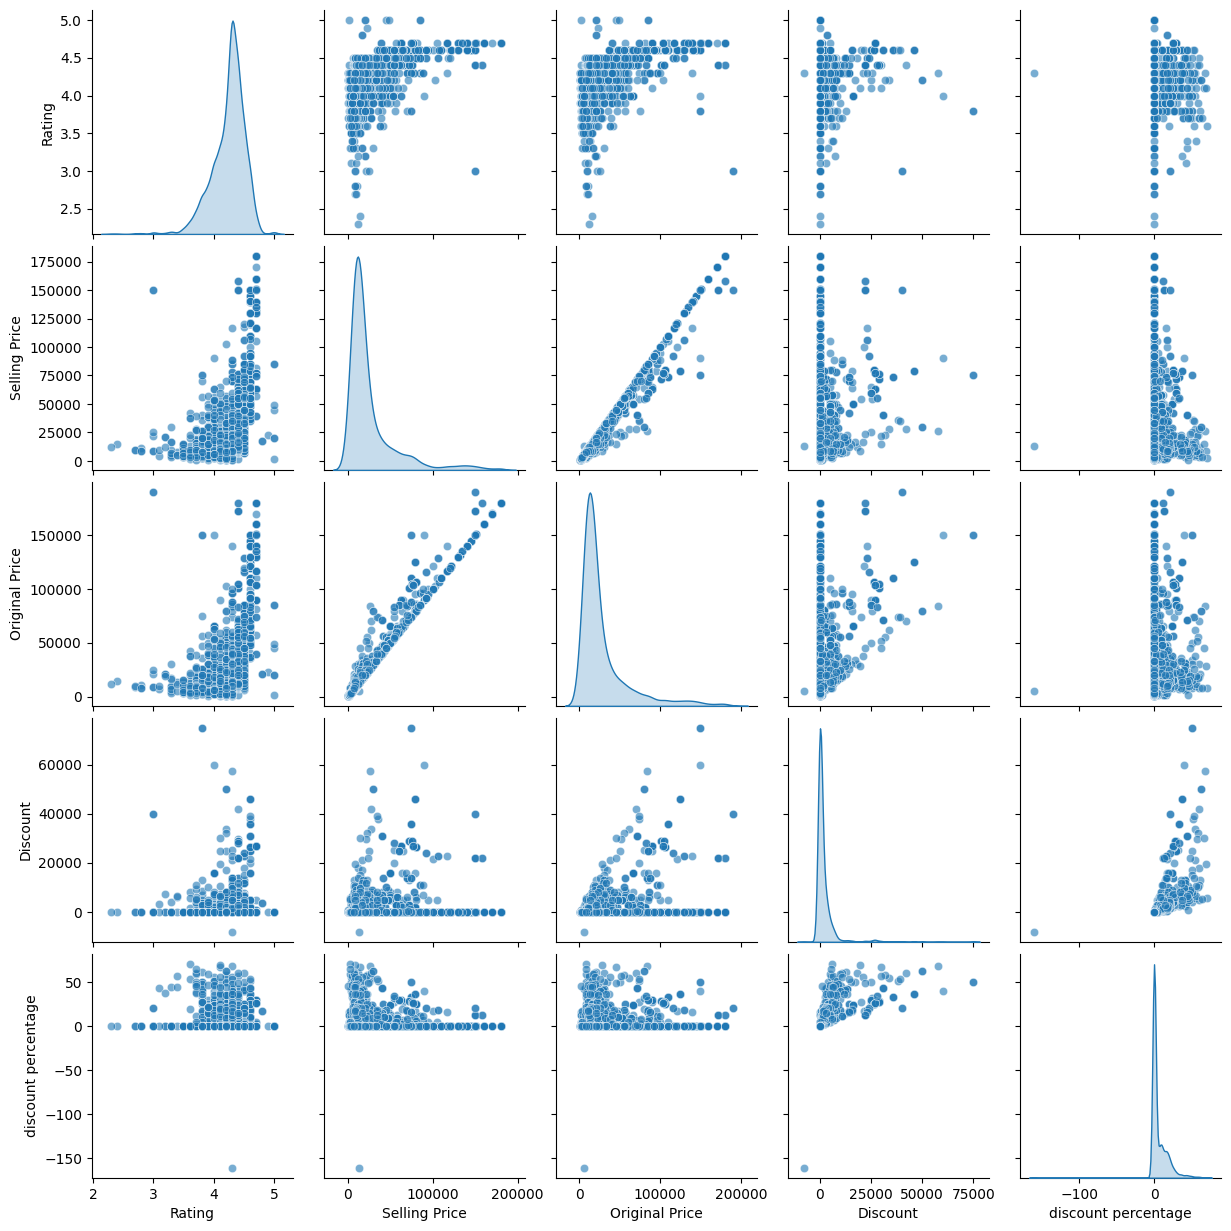

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('/content/file (1).csv')

# 2. Automated Project Summary
print("📊 PROJECT STATS & SUMMARY")
print("-" * 30)
print(f"✅ Data Size: {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"✅ Work Done: Cleaned data, analyzed feature distributions, and calculated correlations.")
print(f"✅ Key Metrics (Averages):")
display(df.mean(numeric_only=True).to_frame(name='Average Value'))

# 3. The "Everything" Visualization
# This creates a pairplot - the ultimate 'stats' visual showing how everything relates
print("\n📈 Visualizing Relationships...")
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.show()